<a href="https://colab.research.google.com/github/sbsudip8/Unemployment_Analysis/blob/main/Umemployment_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Importing Libreries

In [5]:
import pandas as pd
import numpy as np
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

Load dataset

In [6]:
df = pd.read_csv("Unemployment_in_India.csv")
df_covid = pd.read_csv("Unemployment_Rate_upto_11_2020.csv")

View datas

In [7]:
df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


In [9]:
df.shape

(768, 7)

In [10]:
df.isnull().sum()

,0
Region,28
Date,28
Frequency,28
Estimated Unemployment Rate (%),28
Estimated Employed,28
Estimated Labour Participation Rate (%),28
Area,28


In [11]:
df_covid.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Region.1,longitude,latitude
0,Andhra Pradesh,31-01-2020,M,5.48,16635535,41.02,South,15.9129,79.74
1,Andhra Pradesh,29-02-2020,M,5.83,16545652,40.90,South,15.9129,79.74
2,Andhra Pradesh,31-03-2020,M,5.79,15881197,39.18,South,15.9129,79.74
3,Andhra Pradesh,30-04-2020,M,20.51,11336911,33.10,South,15.9129,79.74
4,Andhra Pradesh,31-05-2020,M,17.43,12988845,36.46,South,15.9129,79.74


In [12]:
df_covid.shape

(267, 9)

In [14]:
df_covid.isnull().sum()

,0
Region,0
Date,0
Frequency,0
Estimated Unemployment Rate (%),0
Estimated Employed,0
Estimated Labour Participation Rate (%),0
Region.1,0
longitude,0
latitude,0


Drop Missing Value

In [13]:
df.dropna(inplace=True)

In [15]:
df.isnull().sum()

,0
Region,0
Date,0
Frequency,0
Estimated Unemployment Rate (%),0
Estimated Employed,0
Estimated Labour Participation Rate (%),0
Area,0


In [16]:
df.tail()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
749,West Bengal,29-02-2020,Monthly,7.55,10871168.0,44.09,Urban
750,West Bengal,31-03-2020,Monthly,6.67,10806105.0,43.34,Urban
751,West Bengal,30-04-2020,Monthly,15.63,9299466.0,41.20,Urban
752,West Bengal,31-05-2020,Monthly,15.22,9240903.0,40.67,Urban
753,West Bengal,30-06-2020,Monthly,9.86,9088931.0,37.57,Urban


Cleaning Column name

In [28]:
df.columns = df.columns.str.strip()
df.rename(columns={
    'Region'                          : 'Region',
    'Date'                            : 'Date',
    'Frequency'                       : 'Frequency',
    'Estimated Unemployment Rate (%)'  : 'Unemployment_Rate',
    'Estimated Employed'              : 'Employed',
    'Estimated Labour Participation Rate (%)' : 'Labour_Participation_Rate',
    'Area'                            : 'Area'
}, inplace=True)

In [29]:
df.columns

Index(['Region', 'Date', 'Frequency', 'Unemployment_Rate', 'Employed',
       'Labour_Participation_Rate', 'Area'],
      dtype='object')

In [33]:
df_covid.columns = df_covid.columns.str.strip()
df_covid.rename(columns={
    'Region'                          : 'Region',
    'Date'                            : 'Date',
    'Frequency'                       : 'Frequency',
    'Estimated Unemployment Rate (%)'  : 'Unemployment_Rate',
    'Estimated Employed'              : 'Employed',
    'Estimated Labour Participation Rate (%)' : 'Labour_Participation_Rate',
    'Region.1'                        : 'Region.1',
    'longitude'                       : 'longitude',
    'latitude'                        : 'latitude'
}, inplace=True)

In [34]:
df_covid.columns

Index(['Region', 'Date', 'Frequency', 'Unemployment_Rate', 'Employed',
       'Labour_Participation_Rate', 'Region.1', 'longitude', 'latitude'],
      dtype='object')

Converting Date column to datetime

In [30]:
df['Date'] = pd.to_datetime(df['Date'].str.strip(), dayfirst=True)

# Extract Month and Year
df['Month'] = df['Date'].dt.month
df['Year']  = df['Date'].dt.year
df['Month_Name'] = df['Date'].dt.strftime('%b %Y')

In [35]:
df_covid['Date'] = pd.to_datetime(df_covid['Date'].str.strip(), dayfirst=True)

# Extract Month and Year
df_covid['Month'] = df_covid['Date'].dt.month
df_covid['Year']  = df_covid['Date'].dt.year
df_covid['Month_Name'] = df_covid['Date'].dt.strftime('%b %Y')

Check

In [36]:
df.head()

,Region,Date,Frequency,Unemployment_Rate,Employed,Labour_Participation_Rate,Area,Month,Year,Month_Name
0,Andhra Pradesh,2019-05-31,Monthly,3.65,11999139.0,43.24,Rural,5,2019,May 2019
1,Andhra Pradesh,2019-06-30,Monthly,3.05,11755881.0,42.05,Rural,6,2019,Jun 2019
2,Andhra Pradesh,2019-07-31,Monthly,3.75,12086707.0,43.50,Rural,7,2019,Jul 2019
3,Andhra Pradesh,2019-08-31,Monthly,3.32,12285693.0,43.97,Rural,8,2019,Aug 2019
4,Andhra Pradesh,2019-09-30,Monthly,5.17,12256762.0,44.68,Rural,9,2019,Sep 2019


In [37]:
df_covid.head()

,Region,Date,Frequency,Unemployment_Rate,Employed,Labour_Participation_Rate,Region.1,longitude,latitude,Month,Year,Month_Name
0,Andhra Pradesh,2020-01-31,M,5.48,16635535,41.02,South,15.9129,79.74,1,2020,Jan 2020
1,Andhra Pradesh,2020-02-29,M,5.83,16545652,40.90,South,15.9129,79.74,2,2020,Feb 2020
2,Andhra Pradesh,2020-03-31,M,5.79,15881197,39.18,South,15.9129,79.74,3,2020,Mar 2020
3,Andhra Pradesh,2020-04-30,M,20.51,11336911,33.10,South,15.9129,79.74,4,2020,Apr 2020
4,Andhra Pradesh,2020-05-31,M,17.43,12988845,36.46,South,15.9129,79.74,5,2020,May 2020


In [38]:
print("=== Unemployment Rate Statistics ===")
print(df['Unemployment_Rate'].describe())

print(f"\nOverall average unemployment rate : {df['Unemployment_Rate'].mean():.2f}%")
print(f"Maximum unemployment rate         : {df['Unemployment_Rate'].max():.2f}%")
print(f"Minimum unemployment rate         : {df['Unemployment_Rate'].min():.2f}%")

print("\n=== Average Unemployment Rate by Region ===")
region_avg = df.groupby('Region')['Unemployment_Rate'].mean().sort_values(ascending=False)
print(region_avg.round(2))

=== Unemployment Rate Statistics ===
count    740.000000
mean      11.787946
std       10.721298
min        0.000000
25%        4.657500
50%        8.350000
75%       15.887500
max       76.740000
Name: Unemployment_Rate, dtype: float64

Overall average unemployment rate : 11.79%
Maximum unemployment rate         : 76.74%
Minimum unemployment rate         : 0.00%

=== Average Unemployment Rate by Region ===
Region
Tripura             28.35
Haryana             26.28
Jharkhand           20.58
Bihar               18.92
Himachal Pradesh    18.54
Delhi               16.50
Jammu & Kashmir     16.19
Chandigarh          15.99
Rajasthan           14.06
Uttar Pradesh       12.55
Punjab              12.03
Puducherry          10.22
Kerala              10.12
Tamil Nadu           9.28
Goa                  9.27
Chhattisgarh         9.24
West Bengal          8.12
Telangana            7.74
Maharashtra          7.56
Andhra Pradesh       7.48
Madhya Pradesh       7.41
Sikkim               7.25
Karnataka 

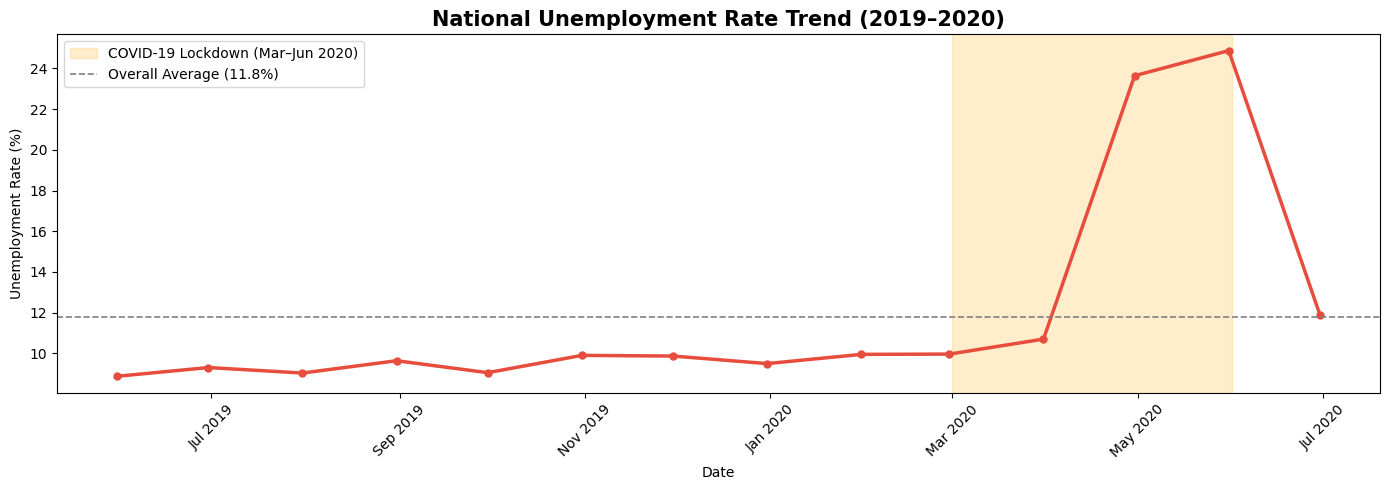

Chart saved.


In [39]:
# Average unemployment rate per month across all regions
monthly_avg = df.groupby('Date')['Unemployment_Rate'].mean().reset_index()

plt.figure(figsize=(14, 5))
plt.plot(monthly_avg['Date'], monthly_avg['Unemployment_Rate'],
         color='#e74c3c', linewidth=2.5, marker='o', markersize=5)

# Highlight Covid-19 period
plt.axvspan(pd.Timestamp('2020-03-01'), pd.Timestamp('2020-06-01'),
            alpha=0.2, color='orange', label='COVID-19 Lockdown (Mar–Jun 2020)')

plt.axhline(y=df['Unemployment_Rate'].mean(), color='gray',
            linestyle='--', linewidth=1.2, label=f"Overall Average ({df['Unemployment_Rate'].mean():.1f}%)")

plt.title('National Unemployment Rate Trend (2019–2020)', fontsize=15, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Unemployment Rate (%)')
plt.legend()
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('trend_over_time.png', dpi=150)
plt.show()
print("Chart saved.")

Average unemployment BEFORE Covid : 9.51%
Average unemployment DURING Covid : 17.77%
Increase                          : +8.26%


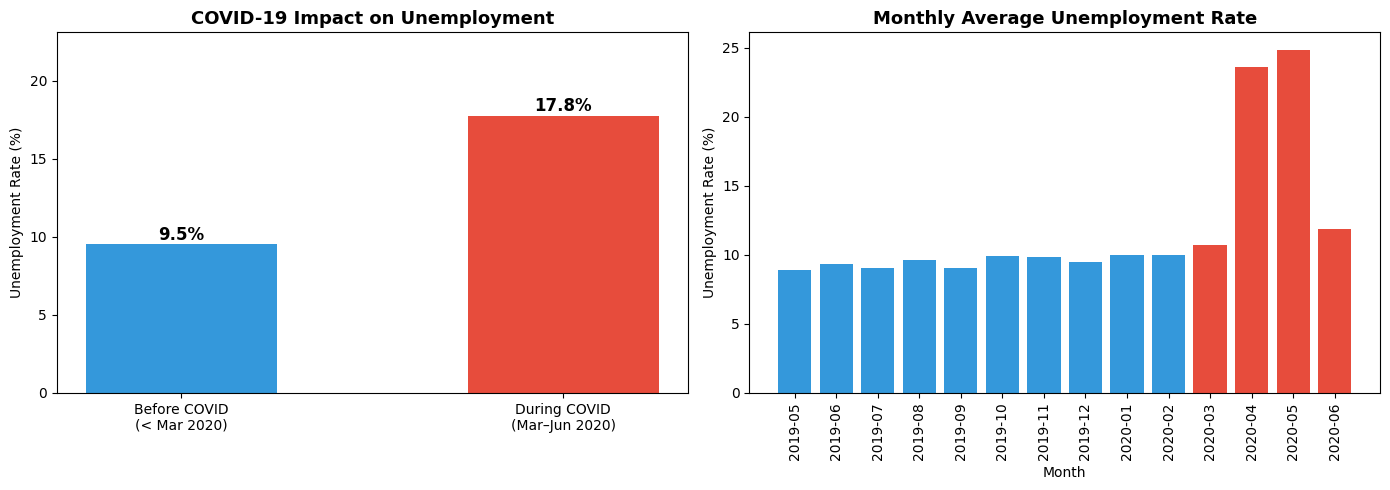

In [40]:
# Split data: Before Covid vs During Covid lockdown
before_covid = df[df['Date'] < '2020-03-01']
during_covid = df[(df['Date'] >= '2020-03-01') & (df['Date'] <= '2020-06-30')]

avg_before = before_covid['Unemployment_Rate'].mean()
avg_during = during_covid['Unemployment_Rate'].mean()

print(f"Average unemployment BEFORE Covid : {avg_before:.2f}%")
print(f"Average unemployment DURING Covid : {avg_during:.2f}%")
print(f"Increase                          : +{avg_during - avg_before:.2f}%")

# Bar chart comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Before vs During
axes[0].bar(['Before COVID\n(< Mar 2020)', 'During COVID\n(Mar–Jun 2020)'],
            [avg_before, avg_during],
            color=['#3498db', '#e74c3c'], width=0.5)
axes[0].set_ylabel('Unemployment Rate (%)')
axes[0].set_title('COVID-19 Impact on Unemployment', fontsize=13, fontweight='bold')
for i, v in enumerate([avg_before, avg_during]):
    axes[0].text(i, v + 0.3, f'{v:.1f}%', ha='center', fontweight='bold', fontsize=12)
axes[0].set_ylim(0, avg_during * 1.3)

# Right: Monthly average bar chart
monthly_bar = df.groupby(df['Date'].dt.to_period('M'))['Unemployment_Rate'].mean()
colors = ['#e74c3c' if str(p) >= '2020-03' and str(p) <= '2020-06' else '#3498db'
          for p in monthly_bar.index]
axes[1].bar(monthly_bar.index.astype(str), monthly_bar.values, color=colors)
axes[1].set_title('Monthly Average Unemployment Rate', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Unemployment Rate (%)')
axes[1].tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.savefig('covid_impact.png', dpi=150)
plt.show()

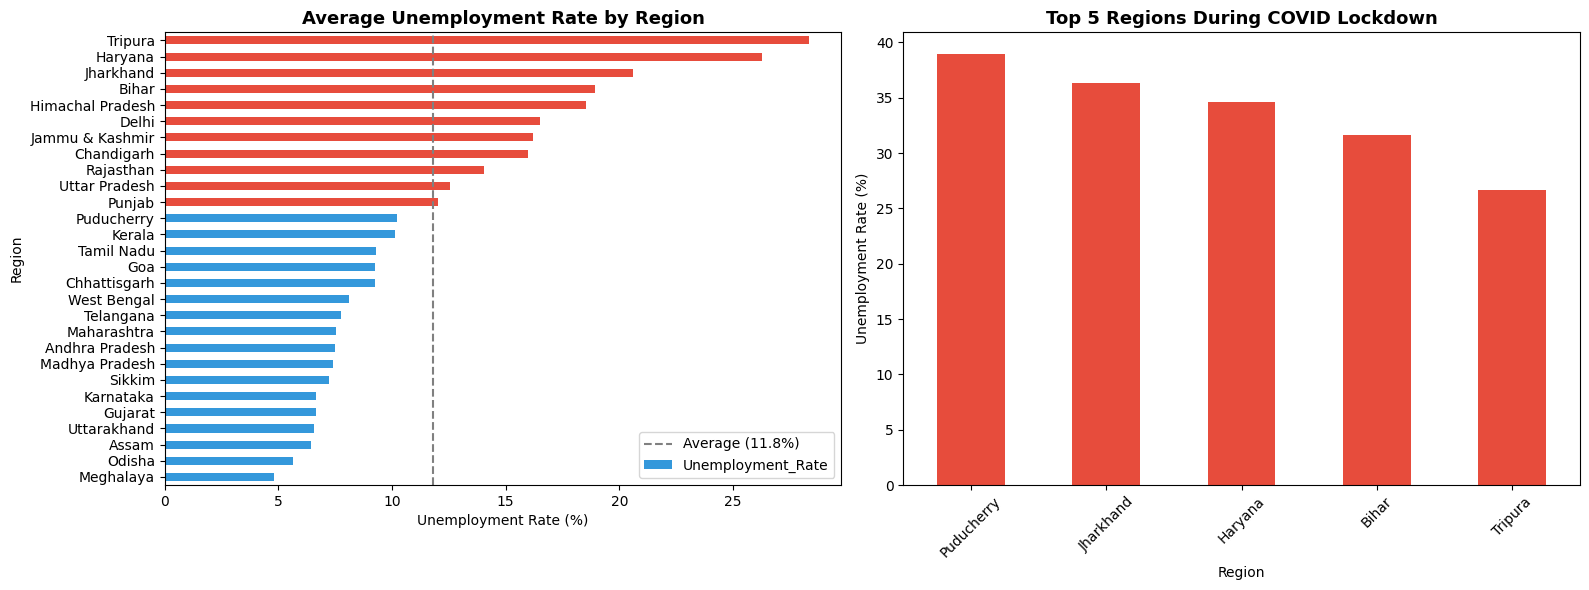

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: Average unemployment rate by region
region_avg_sorted = df.groupby('Region')['Unemployment_Rate'].mean().sort_values()
colors = ['#e74c3c' if v > df['Unemployment_Rate'].mean() else '#3498db'
          for v in region_avg_sorted.values]

region_avg_sorted.plot(kind='barh', ax=axes[0], color=colors)
axes[0].axvline(x=df['Unemployment_Rate'].mean(), color='gray',
                linestyle='--', label=f"Average ({df['Unemployment_Rate'].mean():.1f}%)")
axes[0].set_title('Average Unemployment Rate by Region', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Unemployment Rate (%)')
axes[0].legend()

# Right: Top 5 most affected regions during Covid
top5 = (during_covid.groupby('Region')['Unemployment_Rate']
        .mean().sort_values(ascending=False).head(5))
top5.plot(kind='bar', ax=axes[1], color='#e74c3c')
axes[1].set_title('Top 5 Regions During COVID Lockdown', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Unemployment Rate (%)')
axes[1].set_xlabel('Region')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('regional_analysis.png', dpi=150)
plt.show()

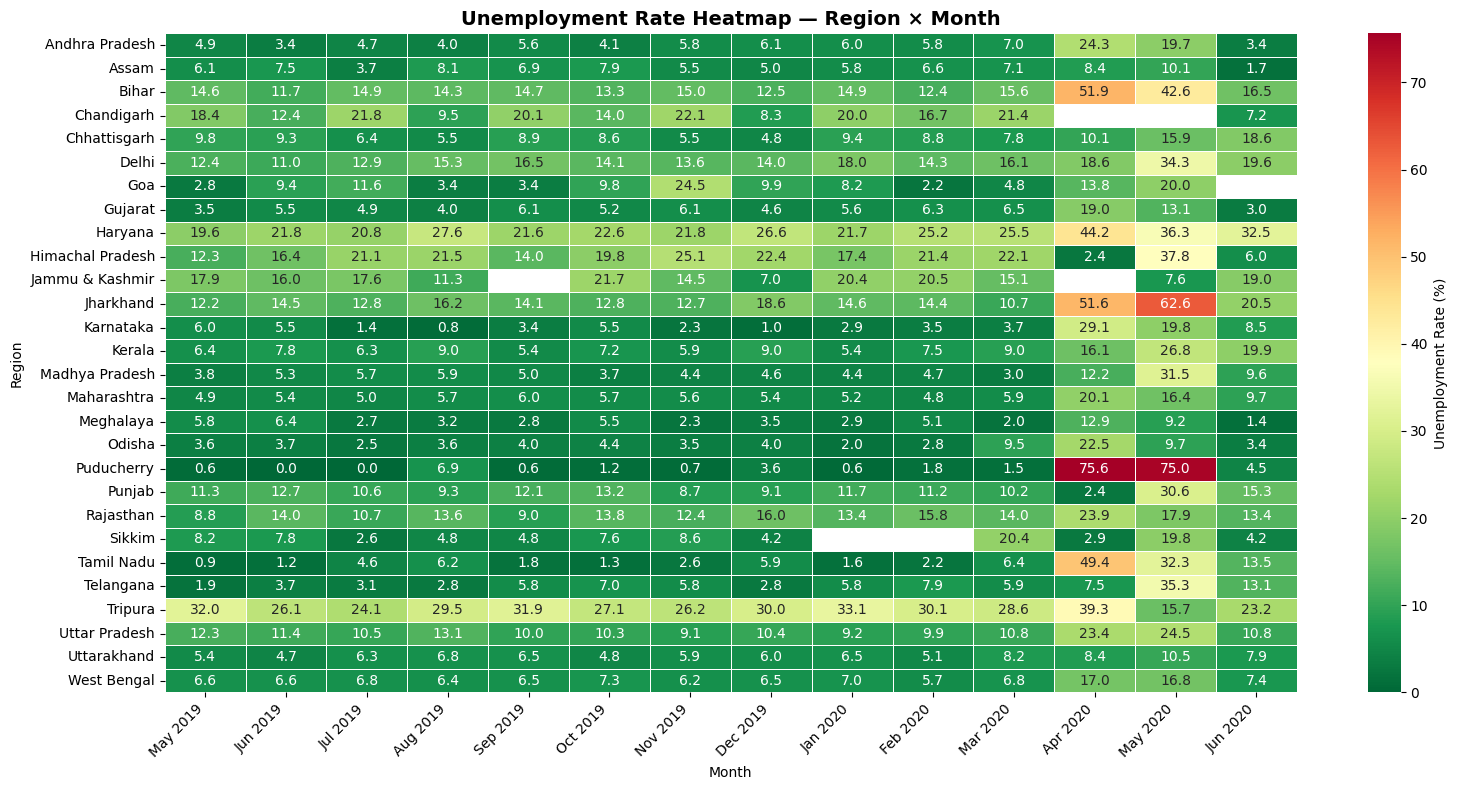

In [44]:
# Pivot table: Region × Month
pivot = df.pivot_table(values='Unemployment_Rate',
                       index='Region',
                       columns=df['Date'].dt.strftime('%b %Y'),
                       aggfunc='mean')

# Sort columns chronologically
pivot = pivot[sorted(pivot.columns, key=lambda x: pd.to_datetime(x, format='%b %Y'))]

plt.figure(figsize=(16, 8))
sns.heatmap(pivot, cmap='RdYlGn_r', annot=True, fmt='.1f',
            linewidths=0.5, cbar_kws={'label': 'Unemployment Rate (%)'})
plt.title('Unemployment Rate Heatmap — Region × Month', fontsize=14, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Region')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('heatmap.png', dpi=150)
plt.show()

SUMMARY STATISTICS

In [45]:
print("\n=== Unemployment Rate Statistics ===")
print(df_covid['Unemployment_Rate'].describe())

print(f"\nOverall average unemployment rate : {df_covid['Unemployment_Rate'].mean():.2f}%")
print(f"Maximum unemployment rate         : {df_covid['Unemployment_Rate'].max():.2f}%")
print(f"Minimum unemployment rate         : {df_covid['Unemployment_Rate'].min():.2f}%")


=== Unemployment Rate Statistics ===
count    267.000000
mean      12.236929
std       10.803283
min        0.500000
25%        4.845000
50%        9.650000
75%       16.755000
max       75.850000
Name: Unemployment_Rate, dtype: float64

Overall average unemployment rate : 12.24%
Maximum unemployment rate         : 75.85%
Minimum unemployment rate         : 0.50%


REGION-WISE ANALYSIS

In [47]:
print("\n=== Average Unemployment Rate by Region ===")

region_avg = (
    df_covid.groupby('Region')['Unemployment_Rate']
    .mean()
    .sort_values(ascending=False)
)

print(region_avg.round(2))


=== Average Unemployment Rate by Region ===
Region
Haryana             27.48
Tripura             25.06
Jharkhand           19.54
Bihar               19.47
Delhi               18.41
Puducherry          17.94
Jammu & Kashmir     16.48
Himachal Pradesh    16.07
Rajasthan           15.87
Tamil Nadu          12.19
Goa                 12.17
Punjab              11.98
Uttarakhand         11.16
West Bengal         10.19
Sikkim               9.79
Uttar Pradesh        9.74
Kerala               9.43
Andhra Pradesh       8.66
Maharashtra          7.98
Chhattisgarh         7.82
Karnataka            7.67
Madhya Pradesh       6.85
Telangana            6.83
Odisha               6.46
Gujarat              6.38
Assam                4.86
Meghalaya            3.87
Name: Unemployment_Rate, dtype: float64


Unemployment trend over time

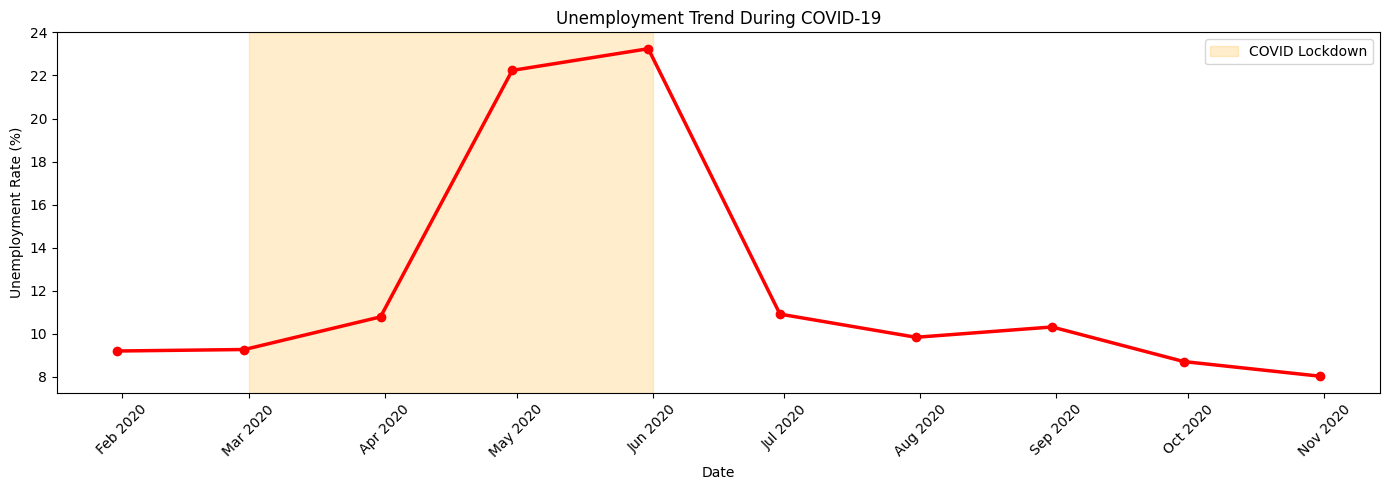

In [50]:
monthly_avg = (
    df_covid.groupby('Date')['Unemployment_Rate']
    .mean()
    .reset_index()
)

plt.figure(figsize=(14,5))

plt.plot(
    monthly_avg['Date'],
    monthly_avg['Unemployment_Rate'],
    marker='o',
    linewidth=2.5,
    color='red'
)

# COVID lockdown highlight
plt.axvspan(
    pd.Timestamp('2020-03-01'),
    pd.Timestamp('2020-06-01'),
    alpha=0.2,
    color='orange',
    label='COVID Lockdown'
)

plt.title('Unemployment Trend During COVID-19')
plt.xlabel('Date')
plt.ylabel('Unemployment Rate (%)')

plt.gca().xaxis.set_major_formatter(
    mdates.DateFormatter('%b %Y')
)

plt.xticks(rotation=45)

plt.legend()

plt.tight_layout()

plt.show()

Before vs during covid

In [51]:
before_covid = df_covid[df_covid['Date'] < '2020-03-01']

during_covid = df_covid[
    (df_covid['Date'] >= '2020-03-01') &
    (df_covid['Date'] <= '2020-06-30')
]

avg_before = before_covid['Unemployment_Rate'].mean()
avg_during = during_covid['Unemployment_Rate'].mean()

print(f"Before COVID : {avg_before:.2f}%")
print(f"During COVID : {avg_during:.2f}%")

Before COVID : 9.23%
During COVID : 16.74%


Covid impact bar chart

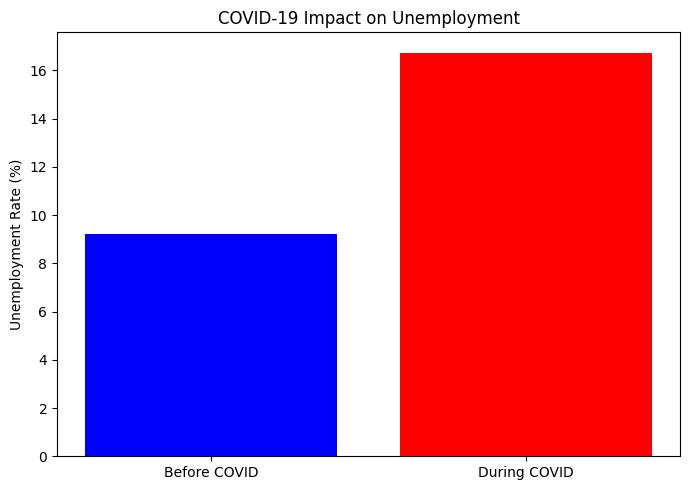

In [52]:
plt.figure(figsize=(7,5))

plt.bar(
    ['Before COVID', 'During COVID'],
    [avg_before, avg_during],
    color=['blue', 'red']
)

plt.ylabel('Unemployment Rate (%)')
plt.title('COVID-19 Impact on Unemployment')

plt.tight_layout()

plt.show()

Region-wise Analysis

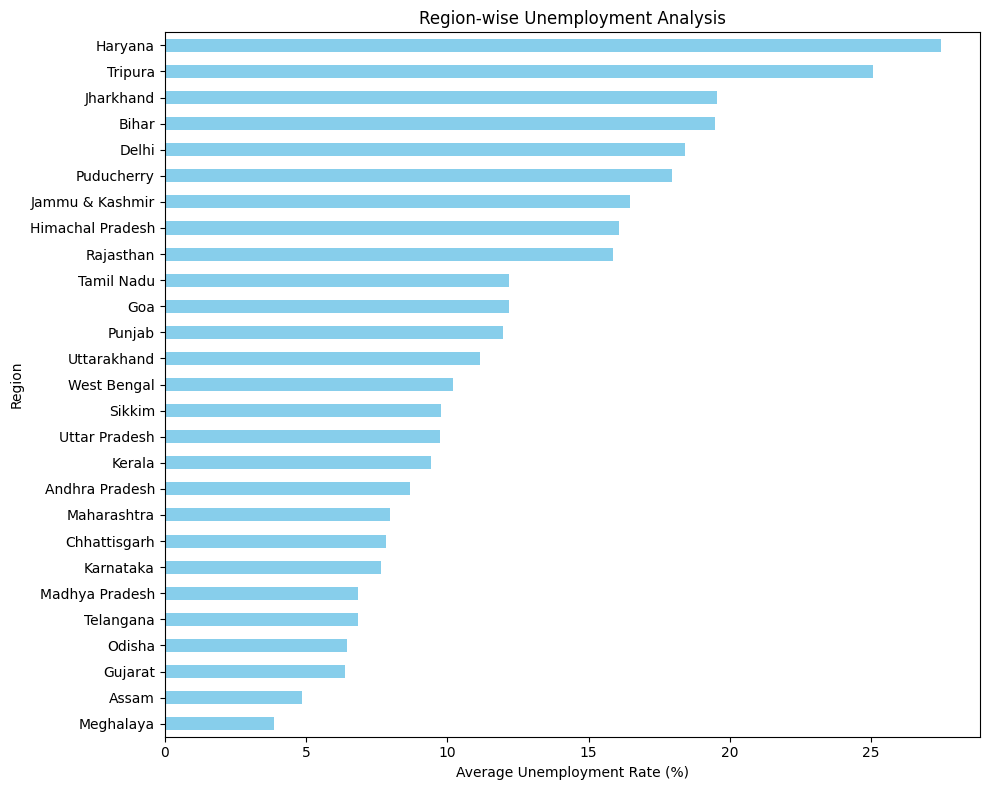

In [53]:
region_avg = (
    df_covid.groupby('Region')['Unemployment_Rate']
    .mean()
    .sort_values()
)

plt.figure(figsize=(10,8))

region_avg.plot(kind='barh', color='skyblue')

plt.xlabel('Average Unemployment Rate (%)')
plt.title('Region-wise Unemployment Analysis')

plt.tight_layout()

plt.show()

Heatmap

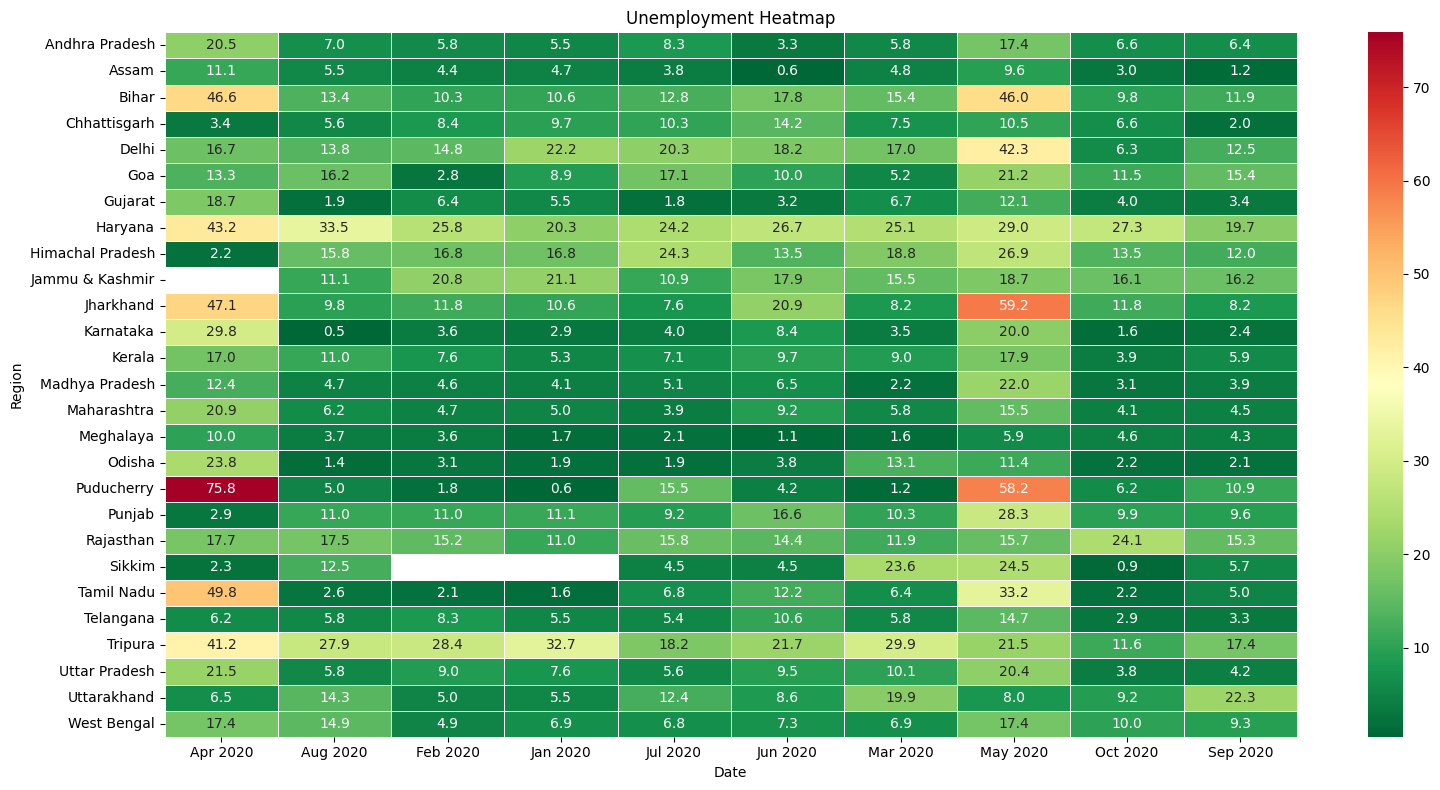

In [54]:
pivot = df_covid.pivot_table(
    values='Unemployment_Rate',
    index='Region',
    columns=df_covid['Date'].dt.strftime('%b %Y'),
    aggfunc='mean'
)

plt.figure(figsize=(16,8))

sns.heatmap(
    pivot,
    cmap='RdYlGn_r',
    annot=True,
    fmt='.1f',
    linewidths=0.5
)

plt.title('Unemployment Heatmap')

plt.tight_layout()

plt.show()